# Predicting Spotify Track Popularity from Audio Features

This notebook walks through the full pipeline: data loading and cleaning, exploratory data analysis (EDA), feature engineering, model training, and evaluation.

## 1. Setup

Import all necessary libraries. `pandas` and `numpy` handle data manipulation, `matplotlib` and `seaborn` handle visualization, and `scipy.stats` is used for hypothesis testing.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import os
os.makedirs("data/raw", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## 2. Load Data

Load the dataset and apply a consistent visual theme. The dataset contains 114,000 Spotify tracks across 114 genre categories, each with 20 columns including audio features and a popularity score (0–100).

In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("data/raw/dataset.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


The dataset has 114,000 rows and 20 columns. Each row is a unique track. The popularity score is our target variable: actual play counts weighted by recency, not user ratings.

## 3. Data Quality Check

Check for missing values and data types across all columns. This tells us what cleaning is needed before any analysis.

In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "null": df.isnull().sum(),
    "null_%": (df.isnull().mean() * 100).round(2)
})
info

,dtype,non_null,null,null_%
track_id,object,114000,0,0.0
artists,object,113999,1,0.0
album_name,object,113999,1,0.0
track_name,object,113999,1,0.0
popularity,int64,114000,0,0.0
duration_ms,int64,114000,0,0.0
explicit,bool,114000,0,0.0
danceability,float64,114000,0,0.0
energy,float64,114000,0,0.0
key,int64,114000,0,0.0


Only one row has missing values (artists, album name, track name). Everything else is complete. Data types look correct as well: audio features are floats, categorical fields are objects or integers.

## 4. Summary Statistics

Compute descriptive statistics for the audio features and popularity. This gives a first look at the range and distribution of each feature.

In [4]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms", "popularity"
]
df[audio_features].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,114000.0,0.156,0.310,0.000,0.000,0.000,0.049,1.000
liveness,114000.0,0.214,0.190,0.000,0.098,0.132,0.273,1.000
valence,114000.0,0.474,0.259,0.000,0.260,0.464,0.683,0.995
tempo,114000.0,122.148,29.978,0.000,99.219,122.017,140.071,243.372
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000


Popularity has a mean of ~33 and a wide standard deviation of ~22, with a minimum of 0. This means that there is a large number of zero-popularity tracks that will need to be handled. Audio features like danceability and energy are bounded in [0, 1] and roughly centered, while loudness is in dB and has a different scale.

## 5. Categorical Overview

Check the number of unique genres, artists, and the split between explicit and non-explicit tracks. This helps understand the diversity and balance of the dataset.

In [5]:
print(f"Unique genres: {df['track_genre'].nunique()}")
print(f"Unique artists: {df['artists'].nunique()}")
print(f"Explicit tracks: {df['explicit'].value_counts().to_dict()}")
print(f"Top 10 genres by track count:")
print(df['track_genre'].value_counts().head(10).to_string())

Unique genres: 114
Unique artists: 31437
Explicit tracks: {False: 104253, True: 9747}
Top 10 genres by track count:
track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000


There are 114 genres and over 31,000 unique artists, making artist-level encoding infeasible without external metadata. The dataset is heavily imbalanced on explicit content as only ~9,700 of 114,000 tracks are explicit.

## 6. Popularity Distribution

Plot the raw popularity distribution and the cleaned version after removing zero-popularity tracks. A large spike at zero indicates tracks with no play history, which represent a structurally different population from tracks with measurable popularity.

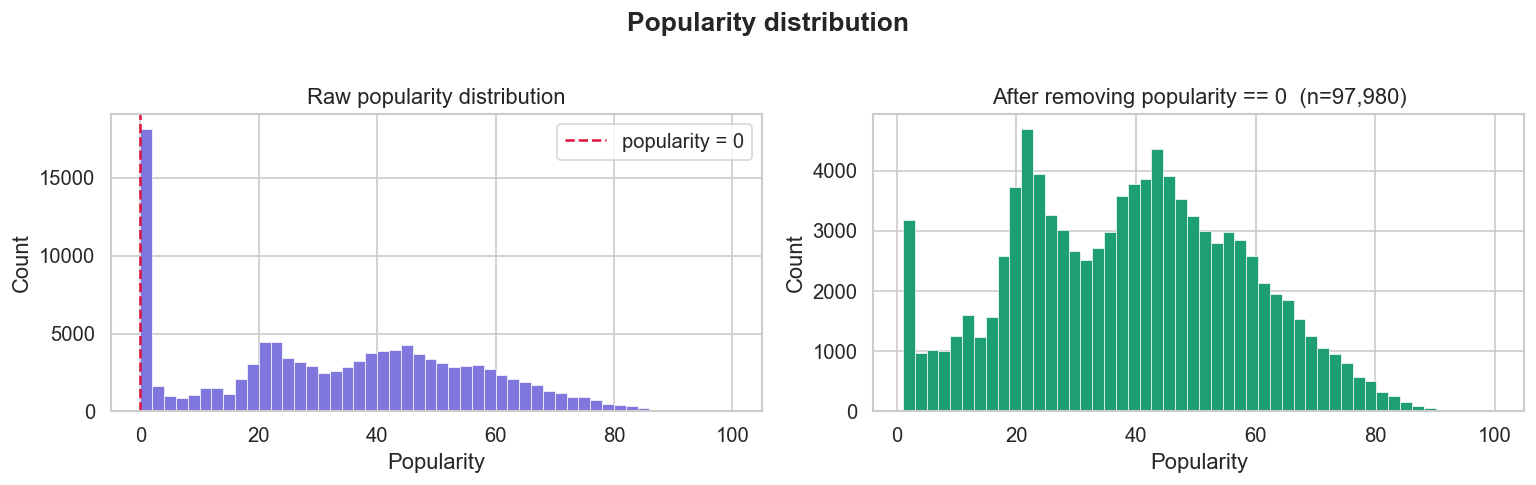

Rows removed (popularity == 0): 16,020
Remaining rows: 97,980
Mean popularity: 38.7
Std popularity: 19.2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["popularity"], bins=50, color="#7F77DD", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw popularity distribution")
axes[0].set_xlabel("Popularity"); axes[0].set_ylabel("Count")
axes[0].axvline(0, color="crimson", lw=1.5, linestyle="--", label="popularity = 0")
axes[0].legend()

df_clean = df[df["popularity"] > 0].copy()
axes[1].hist(df_clean["popularity"], bins=50, color="#1D9E75", edgecolor="white", linewidth=0.4)
axes[1].set_title(f"After removing popularity == 0  (n={len(df_clean):,})")
axes[1].set_xlabel("Popularity"); axes[1].set_ylabel("Count")

plt.suptitle("Popularity distribution", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Rows removed (popularity == 0): {len(df) - len(df_clean):,}")
print(f"Remaining rows: {len(df_clean):,}")
print(f"Mean popularity: {df_clean['popularity'].mean():.1f}")
print(f"Std popularity: {df_clean['popularity'].std():.1f}")

16,020 tracks (14%) have a popularity of exactly zero. These are excluded from all further analysis since predicting a graded score among tracks with no listening history is a different problem. After filtering, 97,980 tracks remain with a mean popularity of 38.7 and standard deviation of 19.2.

## 7. Audio Feature Distributions

Plot histograms for each continuous audio feature. This reveals skew, outliers, and whether any transformations might be needed before modeling.

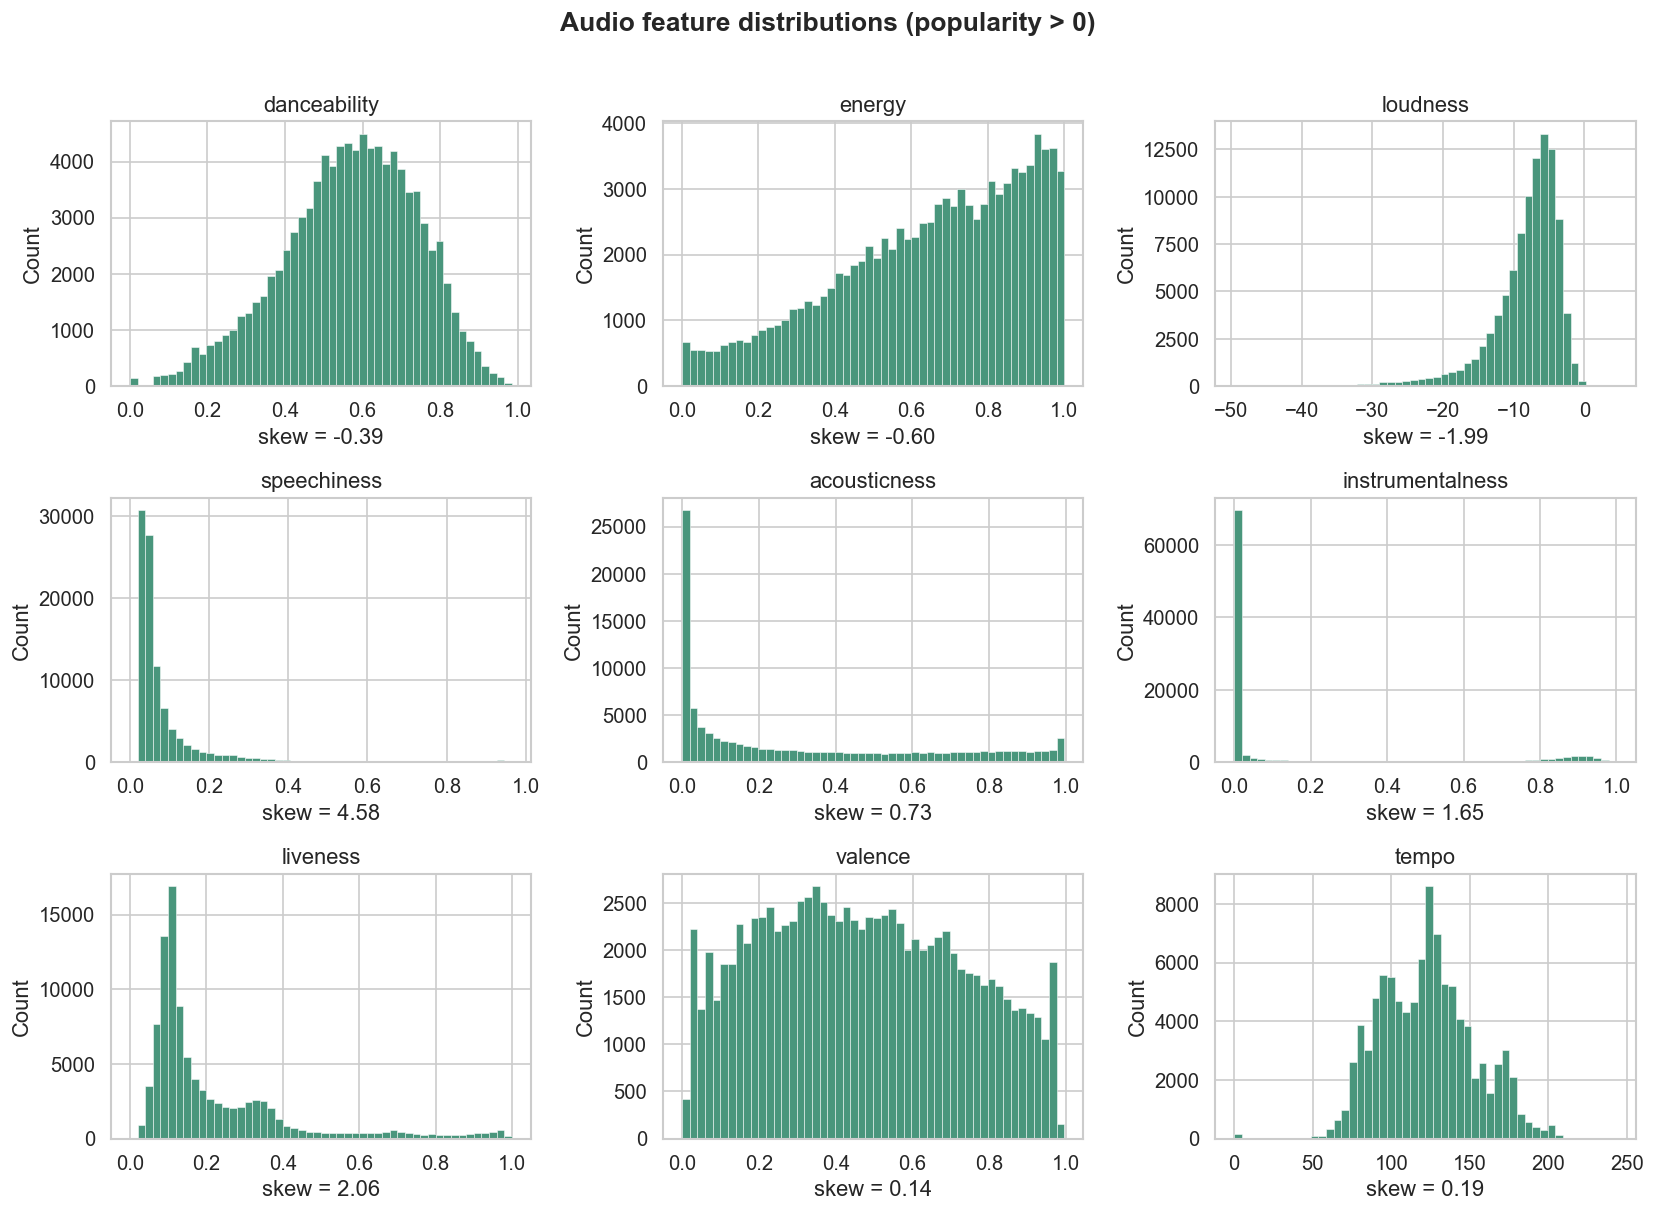

In [7]:
cont_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(cont_features):
    axes[i].hist(df_clean[feat], bins=50, color="#49967C", edgecolor="white", linewidth=0.3)
    axes[i].set_title(feat)
    axes[i].set_ylabel("Count")
    skew = df_clean[feat].skew()
    axes[i].set_xlabel(f"skew = {skew:.2f}")

plt.suptitle("Audio feature distributions (popularity > 0)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Most features are roughly unimodal. Speechiness and instrumentalness are strongly right-skewed,  many tracks have low speech content and near-zero instrumentalness. Duration in milliseconds is also right-skewed, driven by long classical and live recordings. This motivates a log transformation of duration before modeling.

## 8. Feature Correlations

Compute Pearson correlations between all audio features and popularity. This shows which individual features are most linearly related to the target, and highlights any multicollinearity between features.

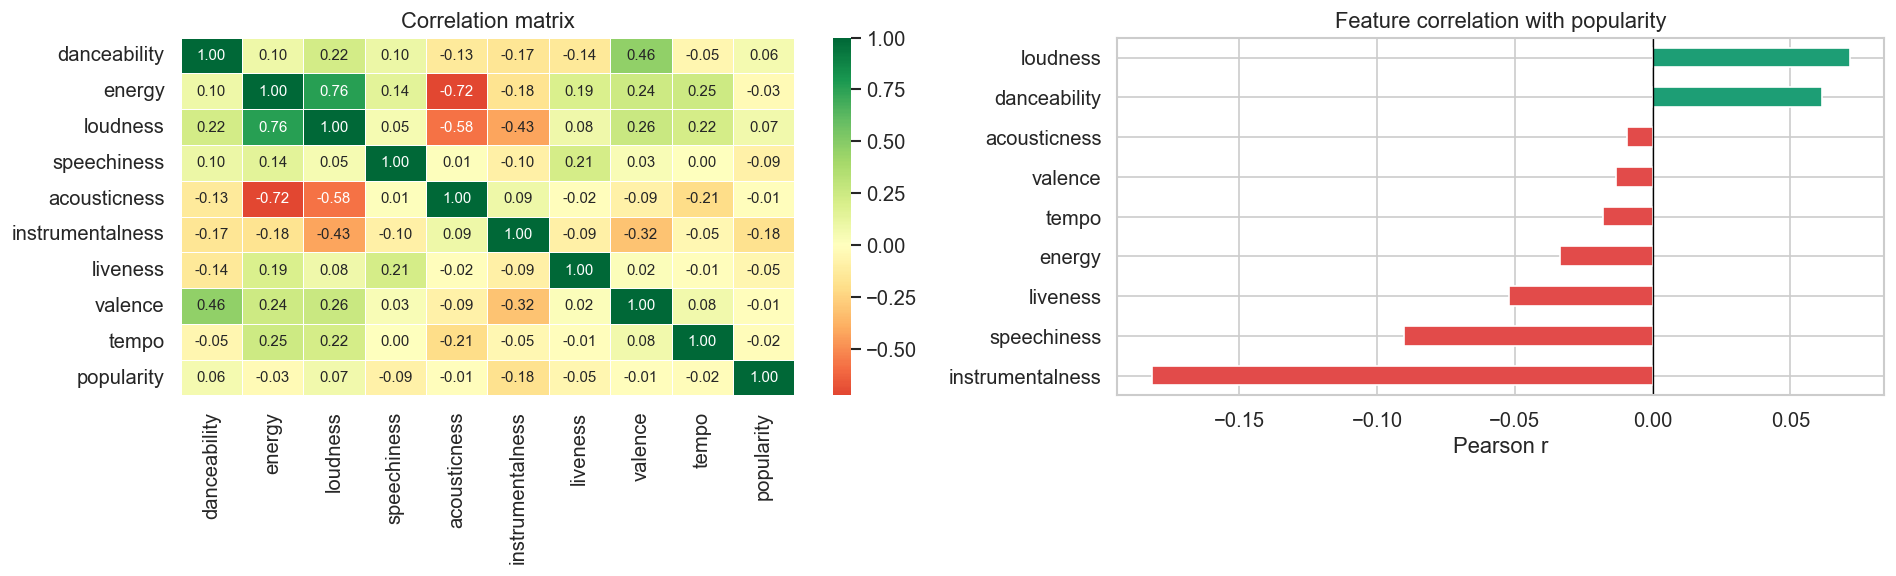

In [8]:
corr_cols = cont_features + ["popularity"]
corr = df_clean[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=axes[0],
    annot_kws={"size": 9}
)
axes[0].set_title("Correlation matrix")

pop_corr = corr["popularity"].drop("popularity").sort_values()
colors = ["#E24B4A" if v < 0 else "#1D9E75" for v in pop_corr]
pop_corr.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature correlation with popularity")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

No single feature exceeds |r| = 0.15 with popularity, meaning no feature is strongly predictive on its own. Loudness has the strongest positive association; acousticness and instrumentalness are negatively correlated. Energy and loudness are correlated at ~0.7 with each other so we deal with this multicollinearity using Ridge's L2 regularization. The low individual correlations suggest that combinations of features and nonlinear interactions matter more than any single predictor.

## 9. Explicit Flag: Energy vs Popularity

Scatter plot of energy vs popularity, colored by explicit flag, with LOWESS smoothing curves. This checks whether explicit and non-explicit tracks show different popularity trends across the energy spectrum.

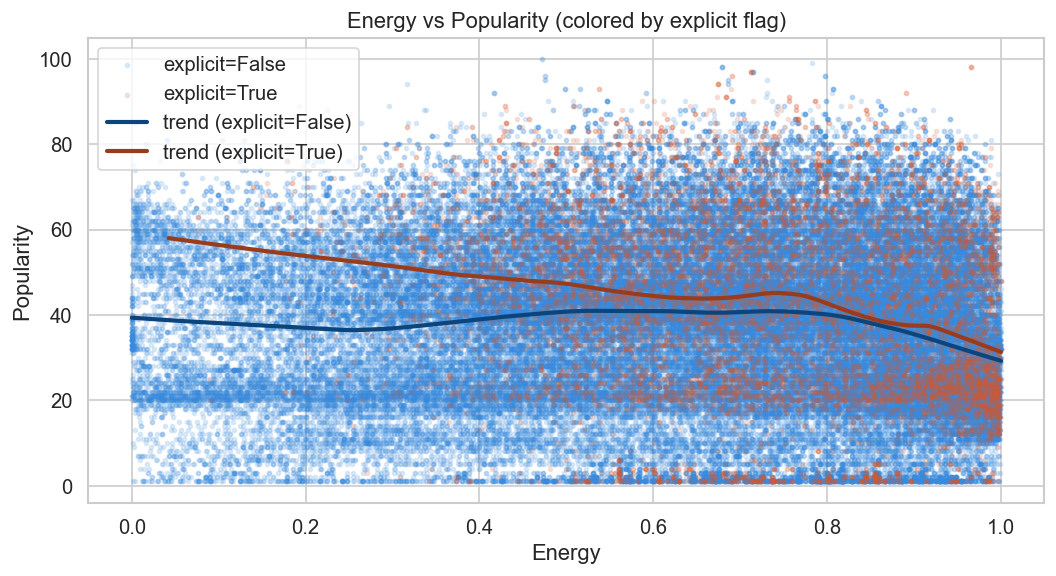

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, color in [(False, "#378ADD"), (True, "#D85A30")]:
    sub = df_clean[df_clean["explicit"] == label]
    ax.scatter(
        sub["energy"], sub["popularity"],
        alpha=0.15, s=6, label=f"explicit={label}", color=color
    )

from statsmodels.nonparametric.smoothers_lowess import lowess
for label, color in [(False, "#0C447C"), (True, "#993C1D")]:
    sub = df_clean[df_clean["explicit"] == label].sample(5000, random_state=42)
    smooth = lowess(sub["popularity"], sub["energy"], frac=0.3)
    ax.plot(smooth[:, 0], smooth[:, 1], color=color, lw=2.5, label=f"trend (explicit={label})")

ax.set_xlabel("Energy"); ax.set_ylabel("Popularity")
ax.set_title("Energy vs Popularity (colored by explicit flag)")
ax.legend(); plt.tight_layout(); plt.show()

Explicit tracks trend slightly higher in popularity across most energy levels. However, the effect is modest and likely confounded by genre: hip-hop and pop genres, which tend to be both explicit and popular, drive much of this signal.

## 10. Hypothesis Test: Explicit vs Non-Explicit Popularity

Boxplot comparing popularity distributions for explicit and non-explicit tracks, with a two-sample t-test to assess whether the difference in means is statistically significant.

/var/folders/2p/_g_t3s7x5gs36t2g0xqvq7d80000gn/T/ipykernel_18124/1711704480.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


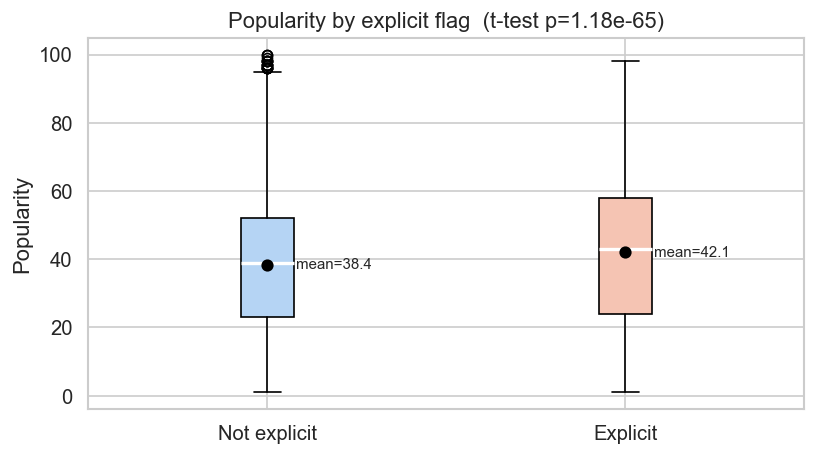

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

expl_groups = df_clean.groupby("explicit")["popularity"]
labels = ["Not explicit", "Explicit"]
data   = [expl_groups.get_group(False), expl_groups.get_group(True)]

bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops=dict(color="white", linewidth=2))
colors = ["#B5D4F4", "#F5C4B3"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

means = [g.mean() for g in data]
for i, m in enumerate(means):
    ax.scatter(i + 1, m, color="black", zorder=5, s=40)
    ax.text(i + 1.08, m, f"mean={m:.1f}", fontsize=9, va="center")

t, p = stats.ttest_ind(data[0], data[1])
ax.set_title(f"Popularity by explicit flag  (t-test p={p:.2e})")
ax.set_ylabel("Popularity")
plt.tight_layout(); plt.show()

The t-test confirms a significant difference (p < 10⁻¹⁰). Explicit tracks have a higher mean popularity. That said, this is seems to be a genre confound rather than a direct causal effect of explicit content. We'll keep the explicit flag as a feature but won't over-interpret its importance.

## 11. Popularity by Genre

Compute mean popularity per genre and plot the top 30. Genre is expected to be one of the strongest predictors — this confirms whether the intuition holds.

/var/folders/2p/_g_t3s7x5gs36t2g0xqvq7d80000gn/T/ipykernel_18124/2141524113.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(genre_pop.index, rotation=45, ha="right", fontsize=9)


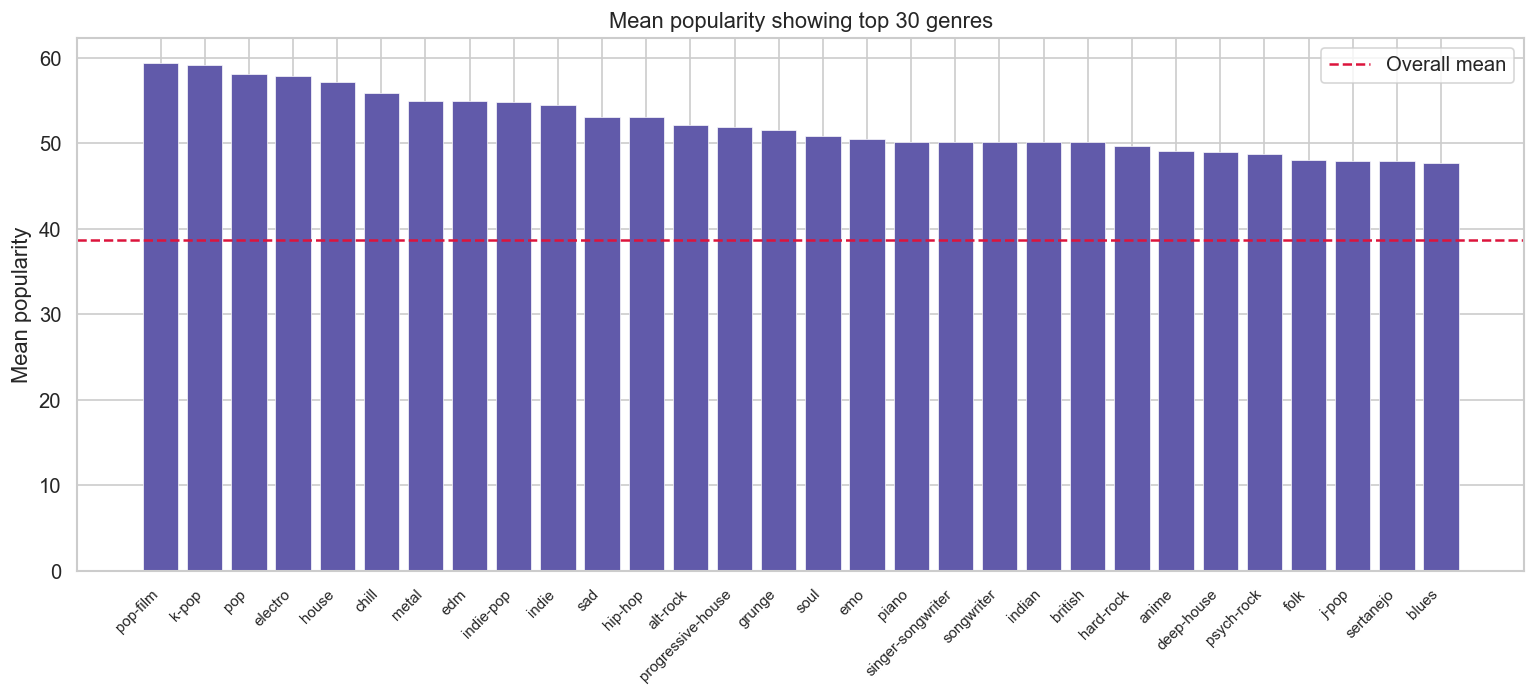

                  mean  median  count
track_genre                          
pop-film     59.401804    60.0    998
k-pop        59.204995    61.0    961
pop          58.161369    67.0    818
electro      57.905297    67.0    623
house        57.212730    66.0    597
chill        55.886458    57.0    960
metal        54.974843    64.0    795
edm          54.909091    63.0    638
indie-pop    54.867746    58.0    741
indie        54.474790    54.0    714


In [11]:
genre_pop = (
    df_clean.groupby("track_genre")["popularity"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(genre_pop.index, genre_pop["mean"], color="#615AAA", edgecolor="white", linewidth=0.4)
ax.set_xticklabels(genre_pop.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean popularity"); ax.set_title("Mean popularity showing top 30 genres")
ax.axhline(df_clean["popularity"].mean(), color="crimson", linestyle="--", lw=1.5, label="Overall mean")
ax.legend(); plt.tight_layout(); plt.show()

print(genre_pop.head(10).to_string())

Pop-film and K-pop top the list at ~59, while folk and classical genres sit near the bottom. The spread of over 20 popularity points between top and bottom genres is larger than the spread attributable to any single continuous audio feature. This strongly motivates including genre as a feature and flags it as likely the most important predictor.

## 12. Feature Interaction Effects

Hexbin plots of danceability × valence and loudness × energy, colored by mean popularity. These reveal whether pairs of features interact nonlinearly in ways that a linear model would miss.

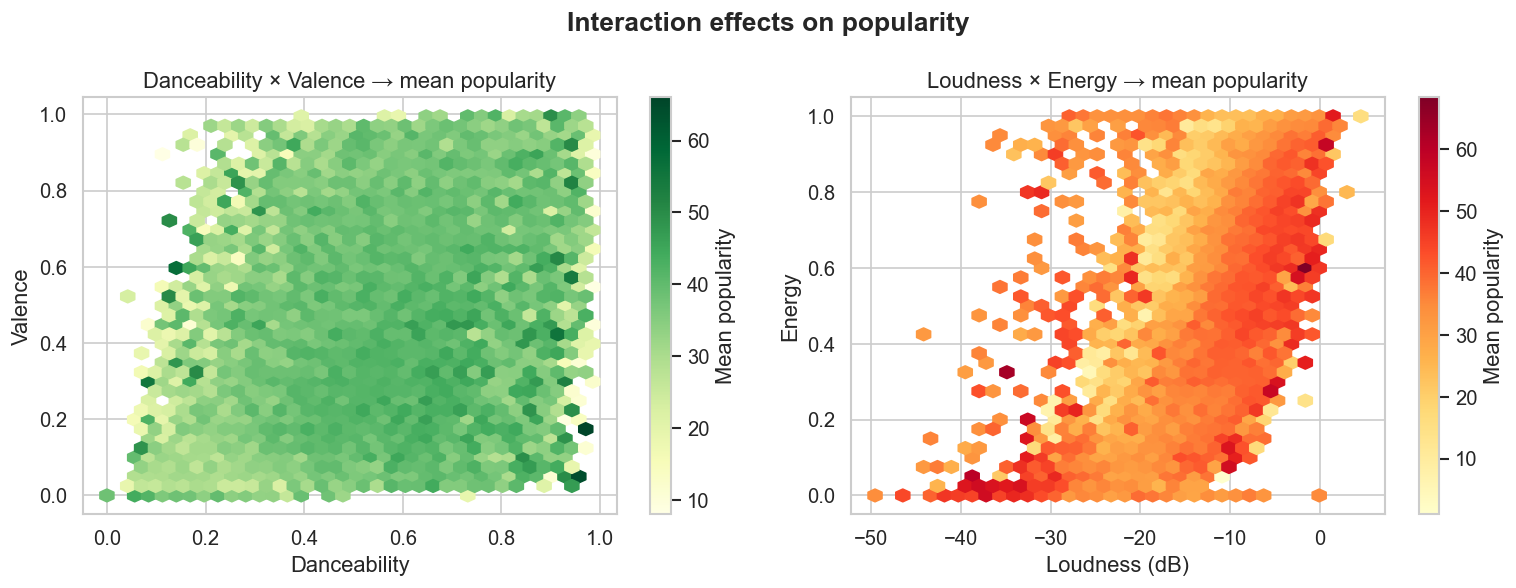

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb = axes[0].hexbin(df_clean["danceability"], df_clean["valence"],
                     C=df_clean["popularity"], reduce_C_function=np.mean,
                     gridsize=35, cmap="YlGn")
plt.colorbar(hb, ax=axes[0], label="Mean popularity")
axes[0].set_xlabel("Danceability"); axes[0].set_ylabel("Valence")
axes[0].set_title("Danceability × Valence → mean popularity")

hb2 = axes[1].hexbin(df_clean["loudness"], df_clean["energy"],
                      C=df_clean["popularity"], reduce_C_function=np.mean,
                      gridsize=35, cmap="YlOrRd")
plt.colorbar(hb2, ax=axes[1], label="Mean popularity")
axes[1].set_xlabel("Loudness (dB)"); axes[1].set_ylabel("Energy")
axes[1].set_title("Loudness × Energy → mean popularity")

plt.suptitle("Interaction effects on popularity", fontweight="bold")
plt.tight_layout(); plt.show()

Both plots show clear nonlinear interaction patterns. High-danceability, high-valence tracks cluster at higher popularity, an upbeat dance music sweet spot. The loudness-energy interaction shows peak popularity at moderately high energy and loudness, declining at extremes. These patterns justify using a tree-based model that can capture such joint effects automatically.

---
## 13. Modeling Setup

Re-import libraries and set a random seed for reproducibility. This section covers feature engineering, model training, and evaluation.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
SEED = 100

## 14. Data Preprocessing

Reload the dataset, filter zero-popularity tracks, encode the explicit flag as a binary integer, and apply a log transformation to duration. Drop columns that are not useful as features (track ID, artist name, album name, track name) to avoid data leakage and identity memorization.

In [14]:
df = pd.read_csv("dataset.csv", index_col=0)

df = df[df["popularity"] > 0].copy()
print(f"Working dataset shape: {df.shape}")

df["explicit"] = df["explicit"].astype(str).str.lower().map({"true": 1, "false": 0})
df["log_duration"] = np.log1p(df["duration_ms"])

DROP_COLS = ["track_id", "artists", "album_name", "track_name", "duration_ms"]
df.drop(columns=DROP_COLS, inplace=True)

df.head()

Working dataset shape: (97980, 20)


,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,log_duration
0,73,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,12.348730
1,55,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,11.915794
2,57,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,12.258793
3,71,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,12.215696
4,82,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,12.200326


The log transformation `log(1 + duration_ms)` compresses the right tail of the duration distribution, making it more symmetric and more linearly related to popularity. After dropping identity columns, 15 raw feature columns remain.

## 15. Feature Definition

Define the feature groups: continuous audio features and categorical features. The final feature matrix has 15 columns before one-hot encoding: 11 continuous and 4 categorical.

In [15]:
TARGET = "popularity"
AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "log_duration", "explicit"
]
CAT_FEATURES = ["key", "mode", "time_signature", "track_genre"]

FEATURES = AUDIO_FEATURES + CAT_FEATURES

X = df[FEATURES]
y = df[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Categorical features:")
for c in CAT_FEATURES:
    print(f"{c}: {X[c].nunique()} unique values")

Feature matrix shape: (97980, 15)
Target shape: (97980,)
Categorical features:
key: 12 unique values
mode: 2 unique values
time_signature: 5 unique values
track_genre: 114 unique values


Track genre alone contributes 114 unique values, which will expand significantly after one-hot encoding. Key (12 values), mode (2), and time signature (5) are also categorical. Together these drive the feature matrix from 15 raw columns to 144 post-encoding columns.

## 16. Train / Validation / Test Split

Split the data into 80% train, 10% validation, and 10% test. The validation set is used only for early stopping during LightGBM training. Final metrics are reported exclusively on the held-out test set.

In [16]:
# 80% train, 10% val, 10% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.10 / 0.80, random_state=SEED
)

print(f"Train: {X_train.shape[0]:>6,} rows")
print(f"Val: {X_val.shape[0]:>6,} rows")
print(f"Test: {X_test.shape[0]:>6,} rows")

Train: 77,159 rows
Val: 11,023 rows
Test:  9,798 rows


The 80/10/10 split gives 77,159 training rows, 11,023 validation rows, and 9,798 test rows. Because genres are already balanced (~1,000 tracks each), genre distribution should be approximately equal across all splits.

## 17. Preprocessing Pipeline

Build a `ColumnTransformer` that standardizes continuous features (zero mean, unit variance) and one-hot encodes categorical features. This is fit on the training set only and applied to all splits to prevent data leakage.

In [17]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, AUDIO_FEATURES),
    ("cat", cat_transformer, CAT_FEATURES),
], remainder="drop")

preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"processed feature count: {X_train_proc.shape[1]}")

processed feature count: 144


After one-hot encoding, the feature matrix expands to 144 columns. Standardization is applied for the Ridge baseline — Ridge's L2 penalty treats all features equally, so features on different scales (e.g. loudness in dB vs danceability in [0,1]) need to be normalized. LightGBM doesn't require it, but uses the same representation for a fair comparison.

## 18. Evaluation Helper

Define a helper function that computes RMSE, MAE, and R² for any set of predictions. RMSE penalizes large errors more heavily, MAE gives an interpretable average error in popularity-score units, and R² measures how much variance the model explains relative to a mean-prediction baseline.

In [18]:
def evaluate(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R²: {r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

## 19. Ridge Regression Baseline

Train a Ridge regression model (α = 1.0) on the training set and evaluate on the validation set. Ridge assumes popularity is a linear combination of the input features and handles multicollinearity via L2 shrinkage. This is for our sanity. Any gain from LightGBM measures the value of nonlinearity.

In [19]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_proc, y_train)

y_val_ridge = ridge.predict(X_val_proc)
results = [evaluate("Ridge (baseline) — Val", y_val, y_val_ridge)]

Ridge (baseline) — Val
RMSE: 15.066
MAE: 10.867
R²: 0.3859


Ridge achieves a validation RMSE of ~15.07 and R² of ~0.386. This is our baseline, or a purely linear model with no interaction terms. LightGBM needs to beat this to justify its added complexity.

## 20. LightGBM Model

Train a LightGBM gradient-boosted tree regressor. LightGBM builds shallow trees sequentially, each fitting the residuals of the previous ensemble. Key hyperparameters: 1,000 max estimators, learning rate 0.05, 63 leaves per tree, 80% row/column subsampling, and L1/L2 regularization. Early stopping with patience 50 prevents overfitting.

In [20]:
lgbm = lgb.LGBMRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    verbose          = -1
)

lgbm.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)]
)

y_val_lgbm = lgbm.predict(X_val_proc)
results.append(evaluate("LightGBM — Val", y_val, y_val_lgbm))

[200]	valid_0's l2: 204.098
[400]	valid_0's l2: 196.767
[600]	valid_0's l2: 190.769
[800]	valid_0's l2: 186.767
[1000]	valid_0's l2: 183.645
LightGBM — Val
RMSE: 13.552
MAE: 9.570
R²: 0.5032


LightGBM achieves a validation RMSE of ~13.55 and R² of ~0.503, a meaningful improvement over Ridge. Training ran the full 1,000 rounds with validation loss still slowly declining, suggesting further gains may be possible with more estimators or explicit hyperparameter tuning.

## 21. Final Test Set Evaluation

Evaluate both models on the held-out test set. This is the first time the test set is used — it was not seen during training or early stopping.

In [21]:
print("\n=== FINAL TEST SET RESULTS ===")

y_test_ridge = ridge.predict(X_test_proc)
results.append(evaluate("Ridge (baseline) — Test", y_test, y_test_ridge))

y_test_lgbm = lgbm.predict(X_test_proc)
results.append(evaluate("LightGBM — Test", y_test, y_test_lgbm))

test_results = pd.DataFrame([r for r in results if "Test" in r["model"]])
test_results


=== FINAL TEST SET RESULTS ===
Ridge (baseline) — Test
RMSE: 15.013
MAE: 10.824
R²: 0.3941
LightGBM — Test
RMSE: 13.679
MAE: 9.608
R²: 0.4970


,model,RMSE,MAE,R2
0,Ridge (baseline) — Test,15.013185,10.824272,0.394119
1,LightGBM — Test,13.679113,9.608441,0.497012


**Ridge:** RMSE 15.013, MAE 10.824, R² 0.394. **LightGBM:** RMSE 13.679, MAE 9.608, R² 0.497. LightGBM outperforms Ridge on all three metrics, with an 8.9% RMSE reduction. Validation and test results are consistent for both models, indicating stable generalization. The ~50% unexplained variance is consistent with prior literature — social and marketing effects that audio features cannot capture likely account for the rest.

## 22. Model Comparison Visualization

Bar charts comparing RMSE, MAE, and R² for Ridge and LightGBM on the test set. Visualizing all three metrics together makes the improvement easy to interpret at a glance.

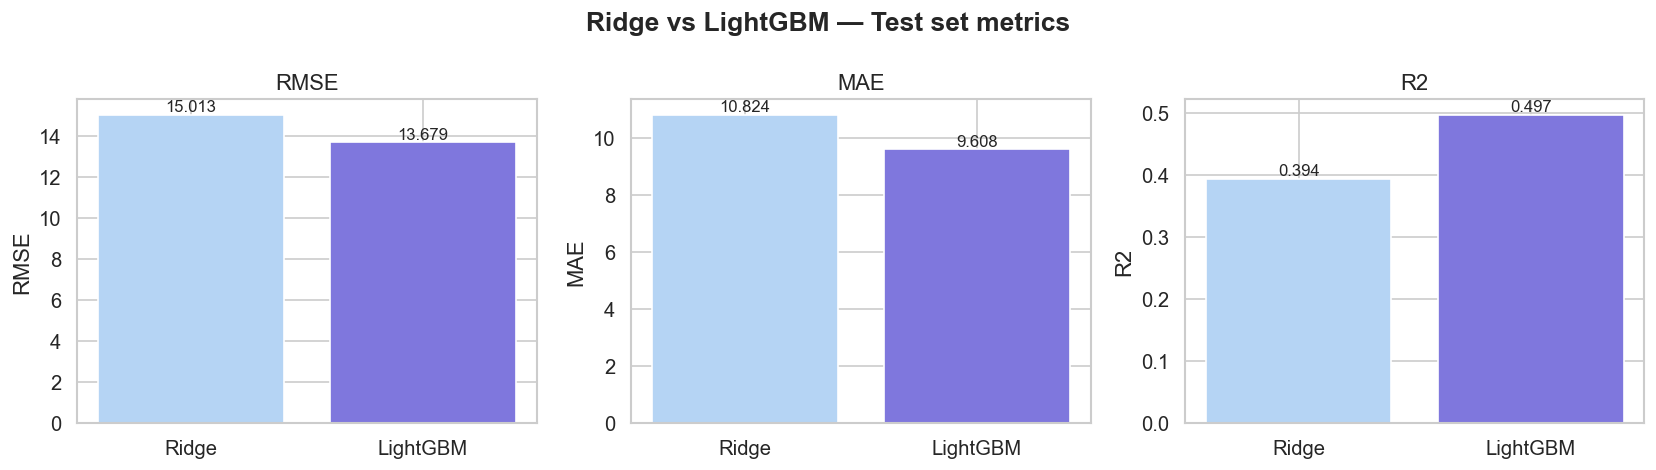

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ["RMSE", "MAE", "R2"]
labels  = ["Ridge", "LightGBM"]
colors  = ["#B5D4F4", "#7F77DD"]

for i, metric in enumerate(metrics):
    vals = [r[metric] for r in results if "Test" in r["model"]]
    bars = axes[i].bar(labels, vals, color=colors, edgecolor="white")
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vals)*0.01,
                     f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("Ridge vs LightGBM — Test set metrics", fontweight="bold")
plt.tight_layout()
plt.show()

## 23. Residual Analysis

Predicted vs actual scatter plots and residual plots for both models. These reveal systematic error patterns — particularly whether the model compresses predictions toward the mean and whether errors are larger at certain popularity ranges.

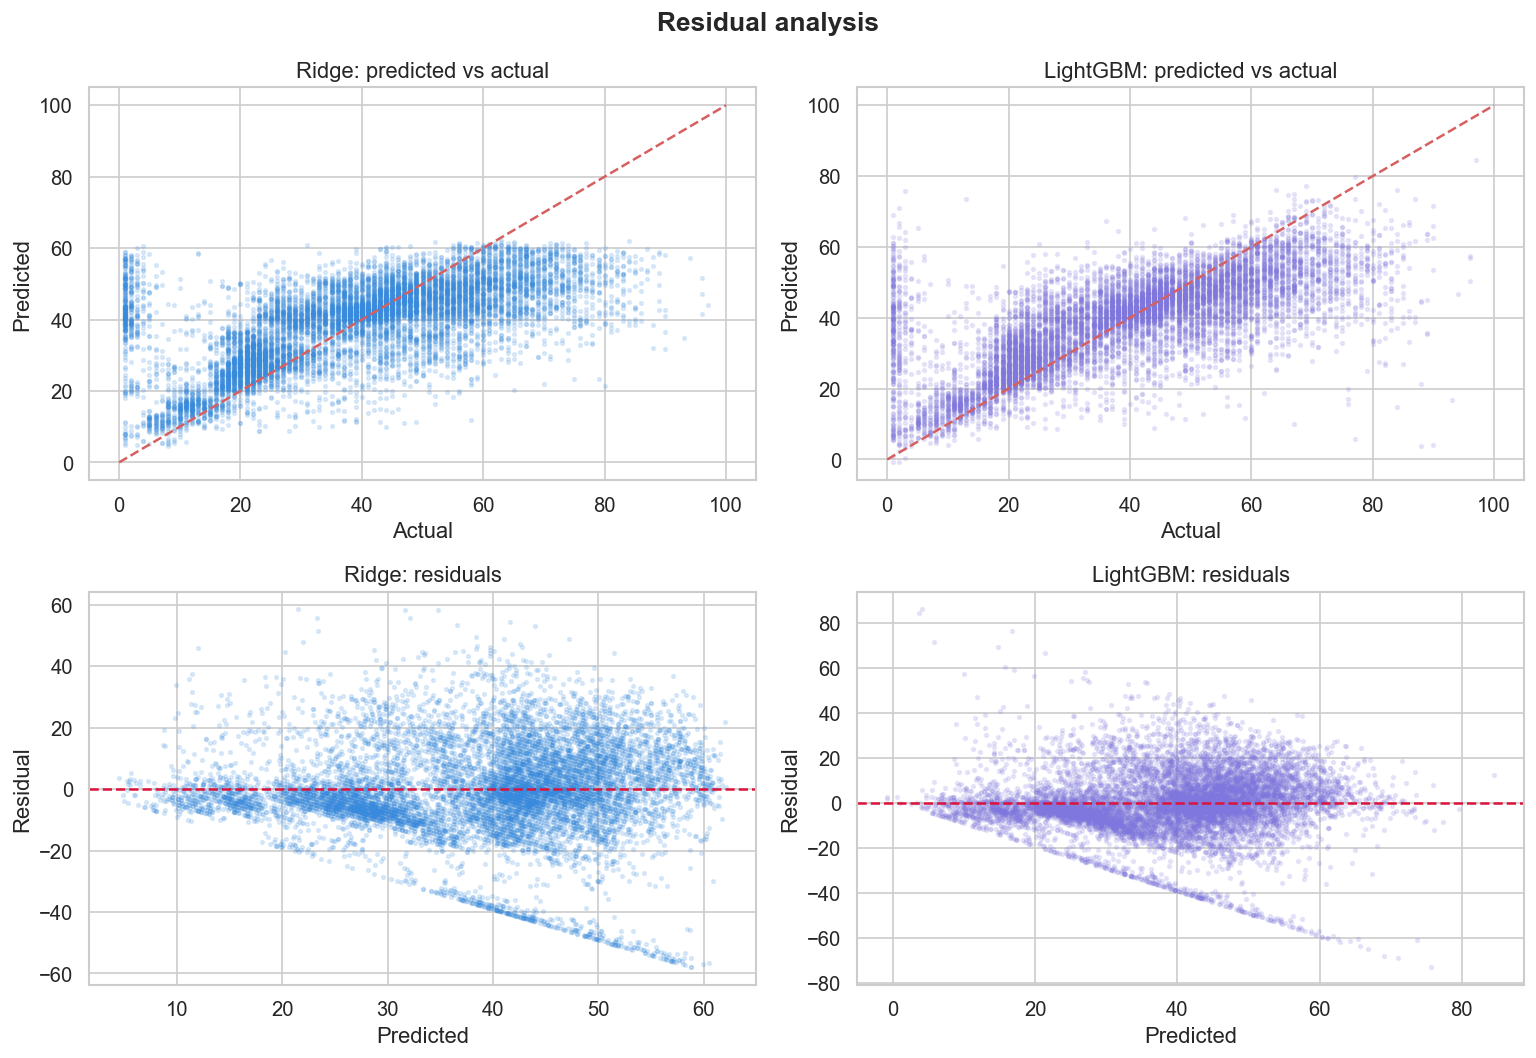

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(y_test, y_test_ridge, alpha=0.15, s=5, color="#378ADD")
axes[0, 0].plot([0, 100], [0, 100], "r--", lw=1.5)
axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Ridge: predicted vs actual")

axes[0, 1].scatter(y_test, y_test_lgbm, alpha=0.15, s=5, color="#7F77DD")
axes[0, 1].plot([0, 100], [0, 100], "r--", lw=1.5)
axes[0, 1].set_xlabel("Actual"); axes[0, 1].set_ylabel("Predicted")
axes[0, 1].set_title("LightGBM: predicted vs actual")

resid_ridge = y_test - y_test_ridge
axes[1, 0].scatter(y_test_ridge, resid_ridge, alpha=0.15, s=5, color="#378ADD")
axes[1, 0].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("Ridge: residuals")

resid_lgbm = y_test - y_test_lgbm
axes[1, 1].scatter(y_test_lgbm, resid_lgbm, alpha=0.15, s=5, color="#7F77DD")
axes[1, 1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1, 1].set_xlabel("Predicted"); axes[1, 1].set_ylabel("Residual")
axes[1, 1].set_title("LightGBM: residuals")

plt.suptitle("Residual analysis", fontweight="bold")
plt.tight_layout()
plt.show()

Both models show the same pattern: predictions cluster in the 30–60 range, underpredicting very popular tracks (>80) and overpredicting low-popularity tracks (<15). This mean compression is typical of regression on noisy targets with moderate R². When uncertain, predicting near the mean minimizes squared error. Errors are largest at both extremes, where audio features carry the least signal.

## 24. Feature Importance

Plot LightGBM's top 25 features by split-count importance. This shows which features the model relied on most when making splits across all 1,000 trees.

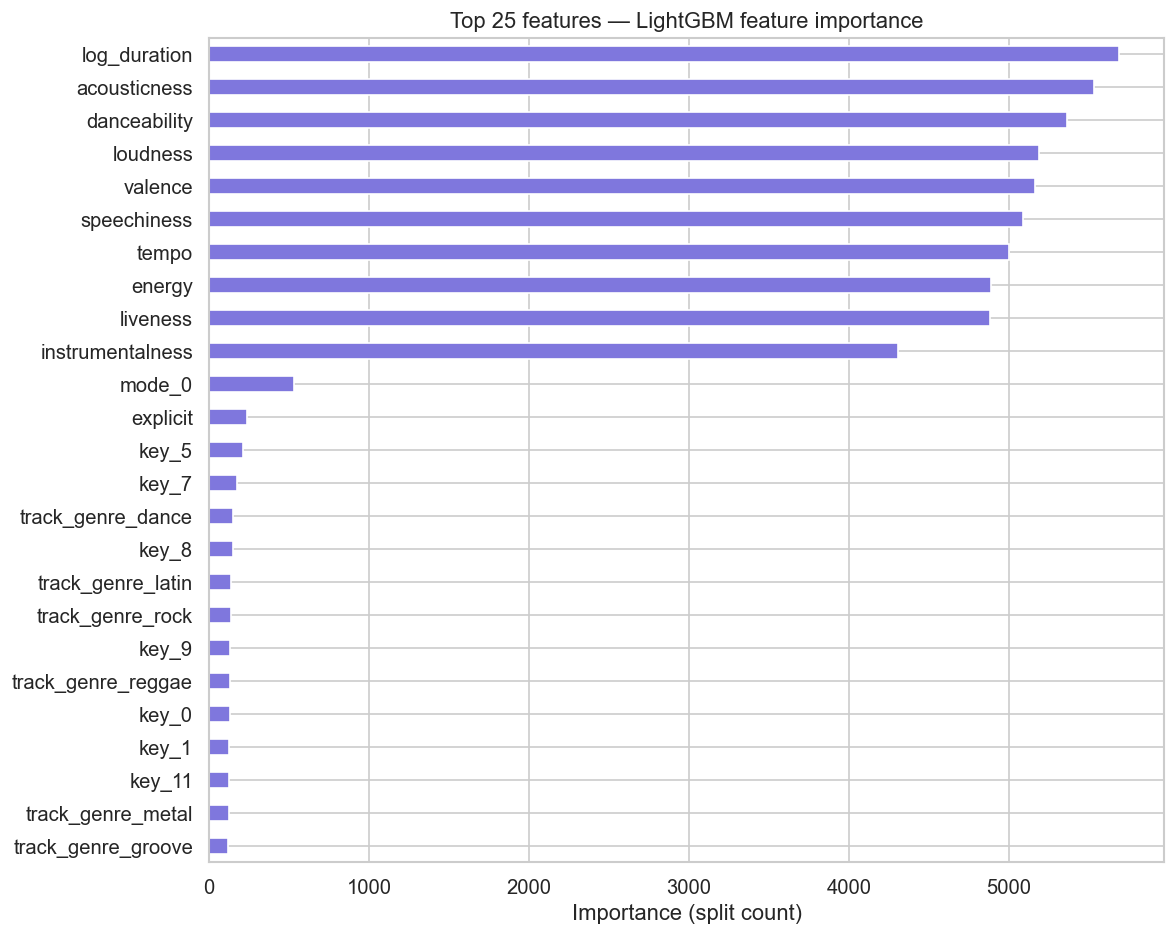

Audio feature importance:
log_duration        5687
acousticness        5531
danceability        5365
loudness            5188
valence             5162
speechiness         5087
tempo               5000
energy              4886
liveness            4879
instrumentalness    4307
explicit             238


In [24]:
num_feature_names = AUDIO_FEATURES
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = num_feature_names + cat_feature_names

importances = pd.Series(lgbm.feature_importances_, index=all_feature_names)
top25 = importances.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
top25[::-1].plot(kind="barh", ax=ax, color="#7F77DD", edgecolor="white")
ax.set_xlabel("Importance (split count)")
ax.set_title("Top 25 features — LightGBM feature importance")
plt.tight_layout()
plt.show()

print("Audio feature importance:")
print(importances[AUDIO_FEATURES].sort_values(ascending=False).to_string())

The top continuous predictors are log_duration (5,687 splits), acousticness (5,531), danceability (5,365), loudness (5,188), and valence (5,162). The explicit flag barely registers (238 splits), likely because its signal is absorbed by genre. Genre indicators collectively dominate the top-25 list, confirming the EDA finding that genre encodes more about popularity than any individual audio feature.

## 25. Error Analysis by Genre

Compute mean absolute error per genre on the test set and plot the top 20 worst-performing genres. This identifies where the model struggles most and gives insight into what additional features might help.

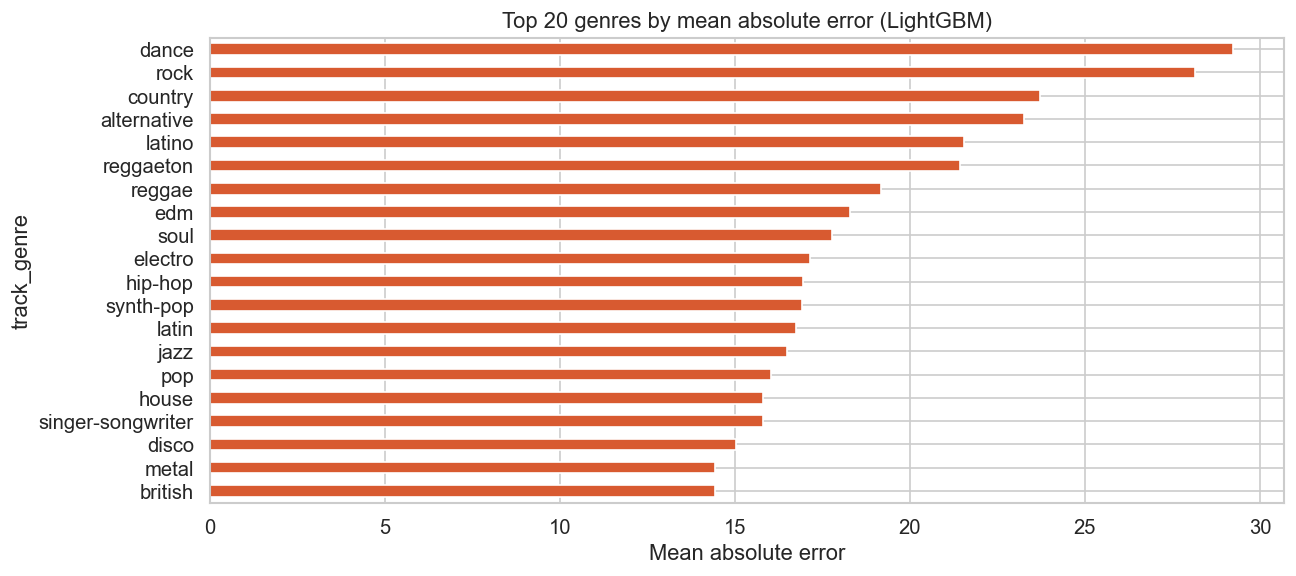

In [25]:
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_test_lgbm
test_df["abs_error"] = np.abs(test_df["actual"] - test_df["predicted"])

genre_err = (
    test_df.groupby("track_genre")["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 5))
genre_err[::-1].plot(kind="barh", ax=ax, color="#D85A30", edgecolor="white")
ax.set_xlabel("Mean absolute error")
ax.set_title("Top 20 genres by mean absolute error (LightGBM)")
plt.tight_layout()
plt.show()

The model does best on genres with consistent audio profiles (e.g. certain electronic subgenres) and worst on genres where popularity is culturally or socially driven. K-pop is a clear example because its popularity depends heavily on fan mobilization and social media campaigns, not danceability or energy. For these genres, artist-level features (follower count, prior release popularity) would likely close most of the gap.

## 26. Save Figures

Save all key figures as PDFs to the `figures/` directory for inclusion in the written report. Each figure is regenerated here to ensure clean, high-resolution output.

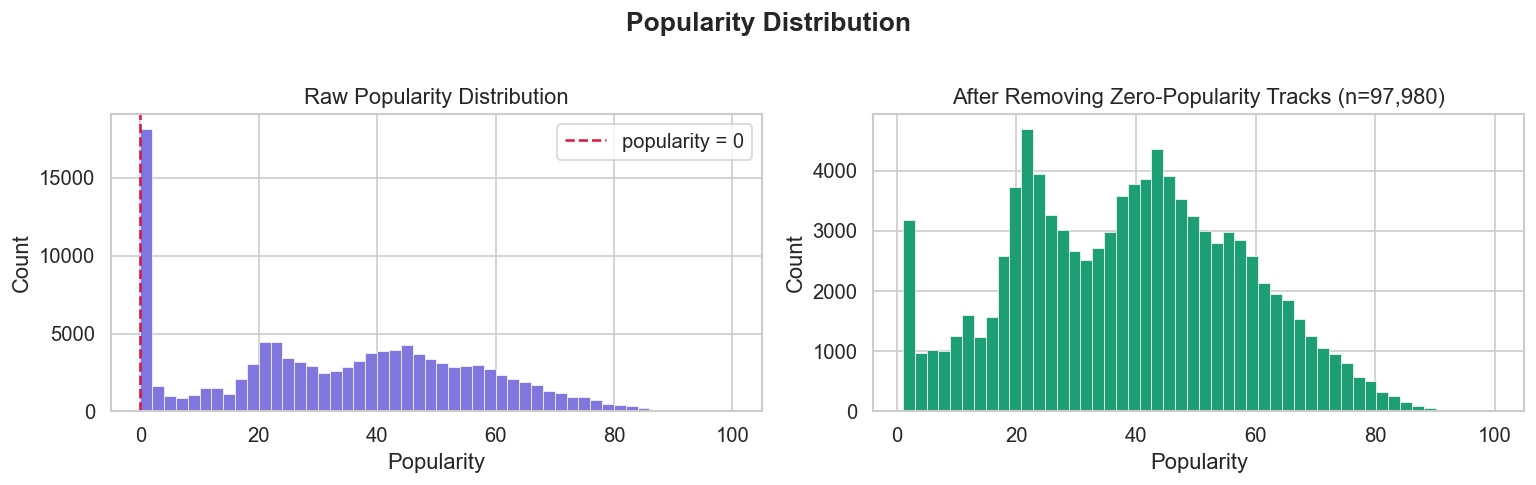

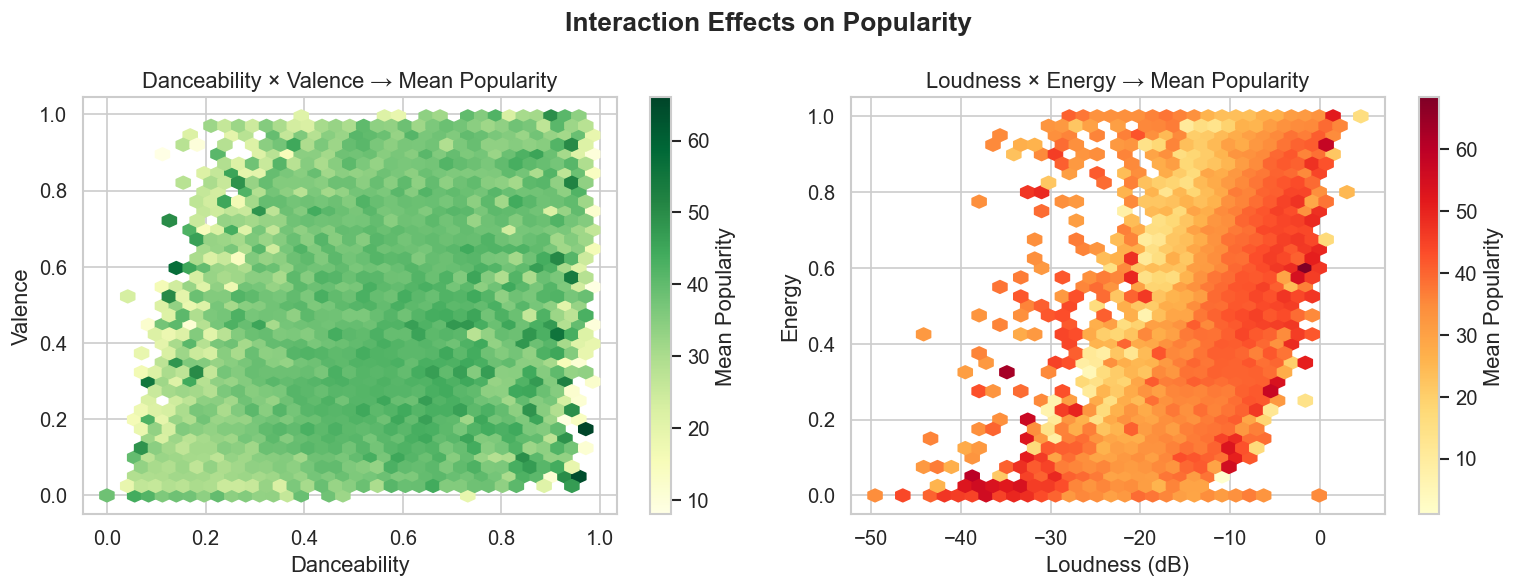

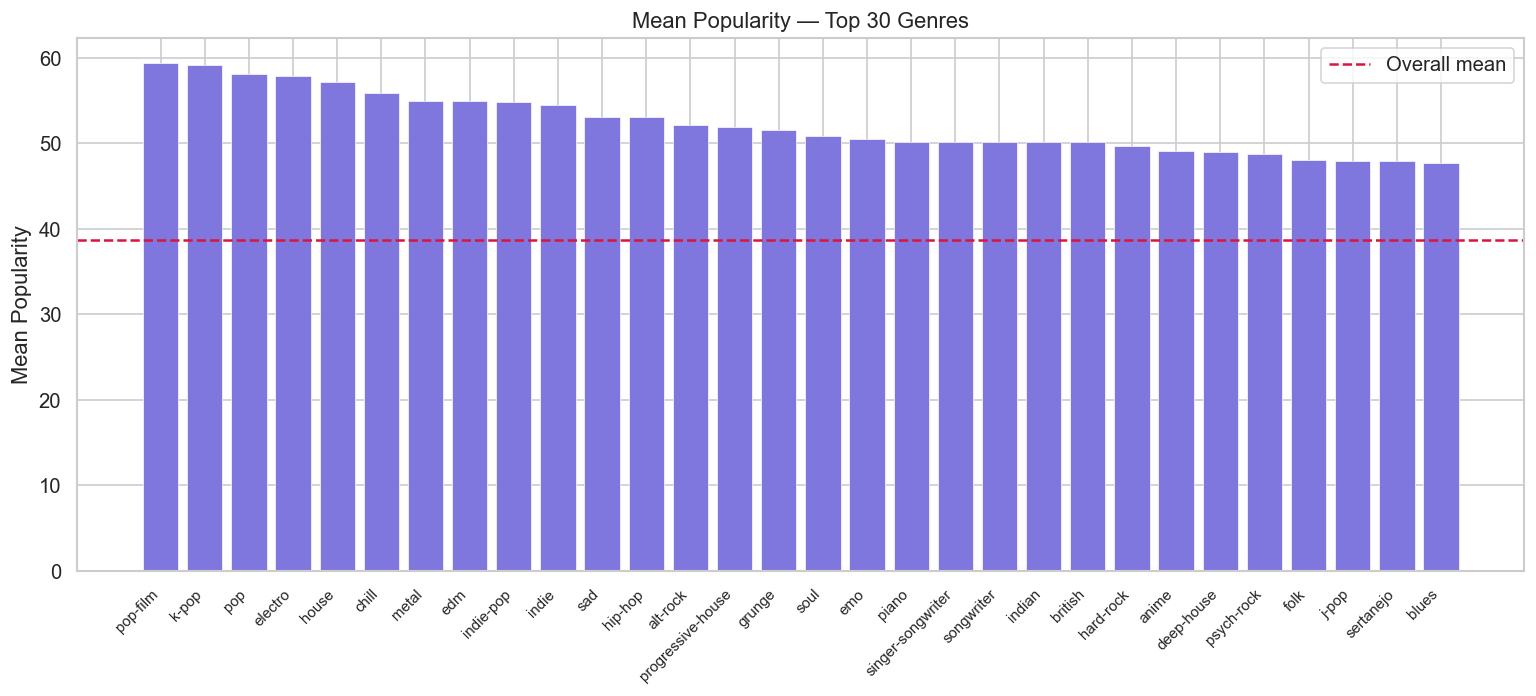

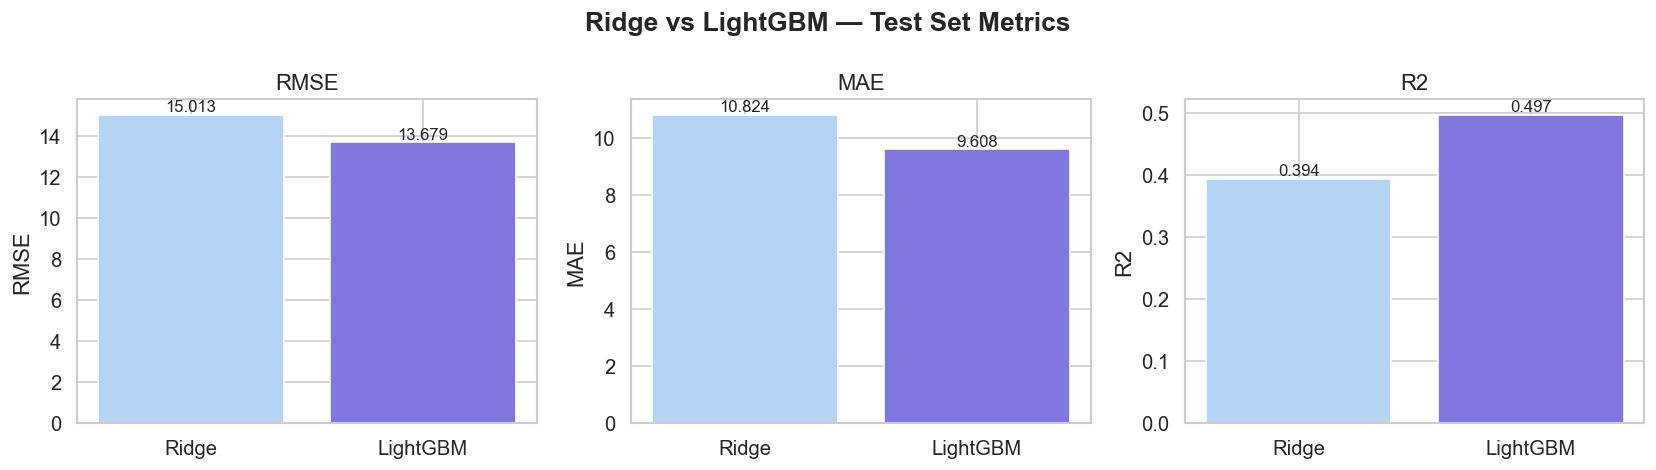

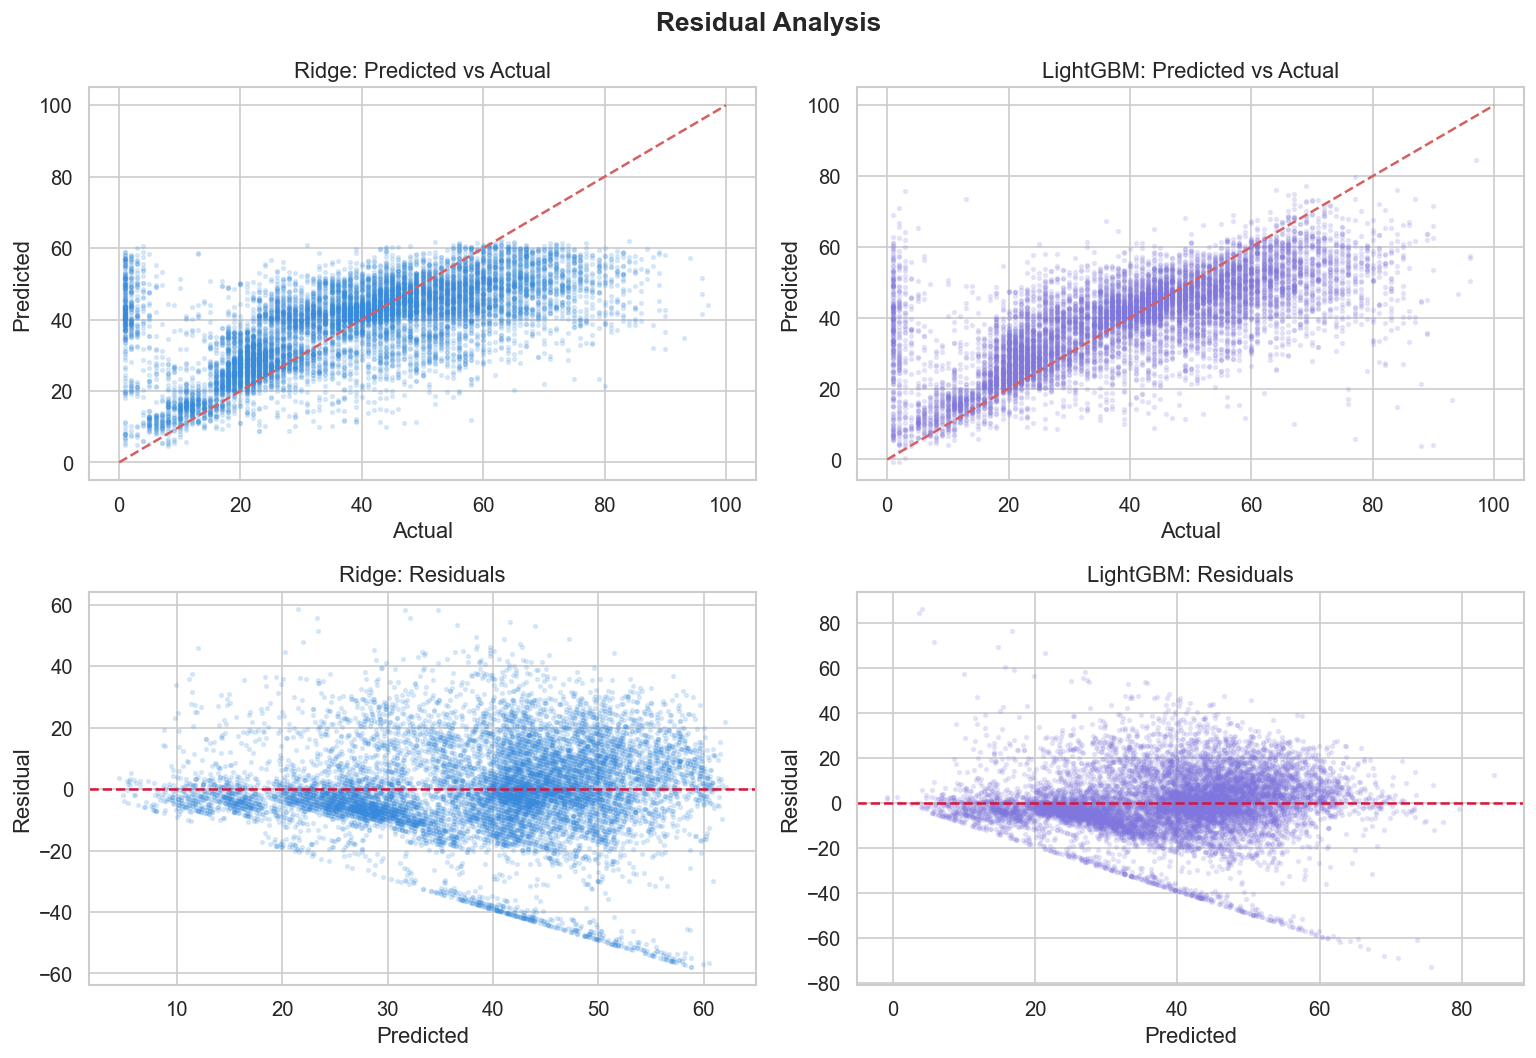

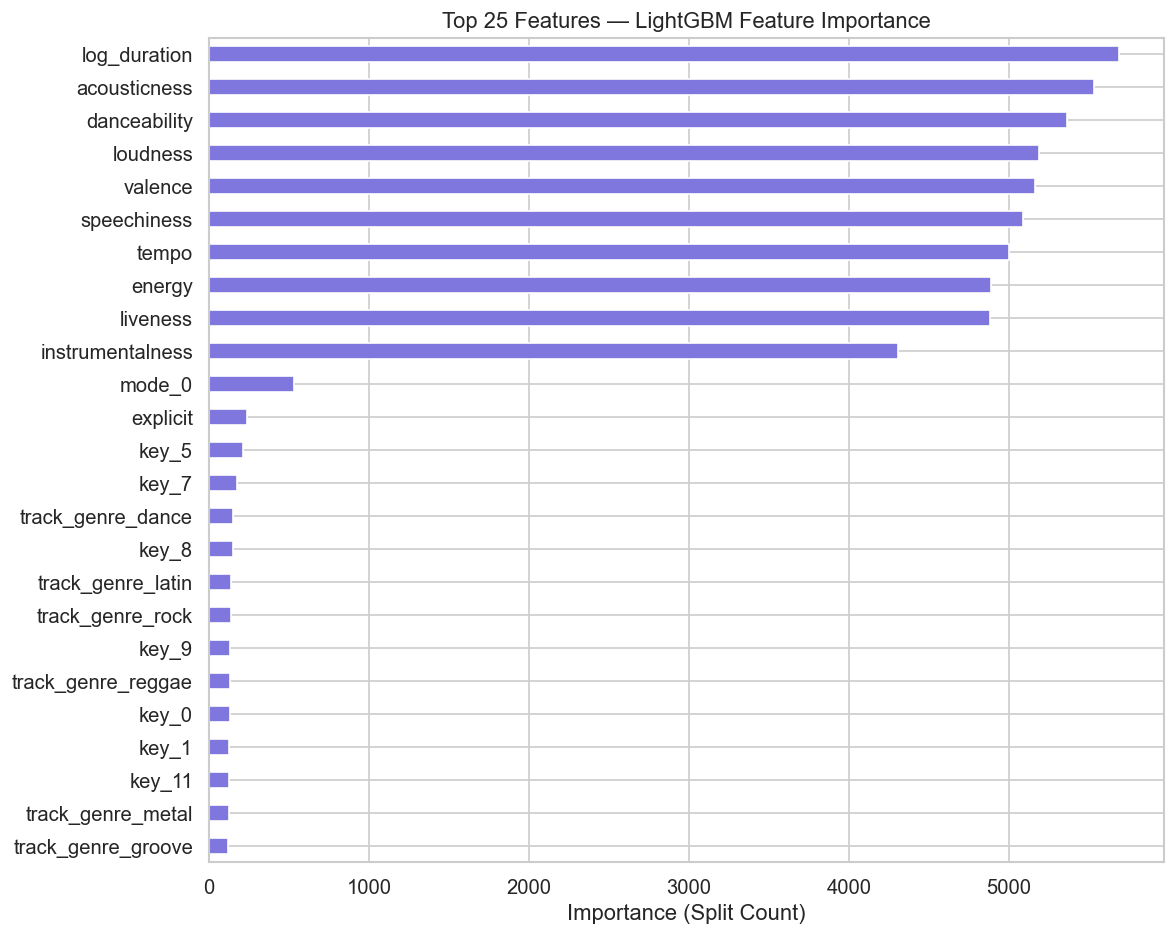

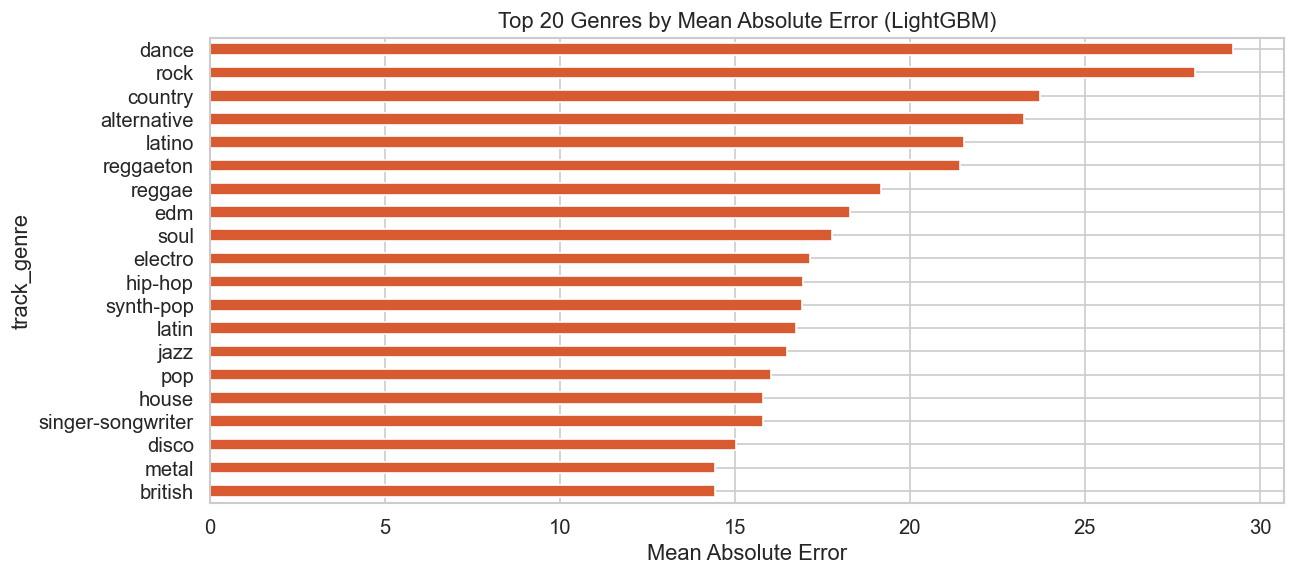

In [26]:
import os
os.makedirs("figures", exist_ok=True)

#Figure 1: popularity distribution (raw n cleaned)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_all = pd.read_csv("dataset.csv", index_col=0)
df_clean_fig = df_all[df_all["popularity"] > 0].copy()

axes[0].hist(df_all["popularity"], bins=50, color="#7F77DD", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Popularity Distribution")
axes[0].set_xlabel("Popularity"); axes[0].set_ylabel("Count")
axes[0].axvline(0, color="crimson", lw=1.5, linestyle="--", label="popularity = 0")
axes[0].legend()

axes[1].hist(df_clean_fig["popularity"], bins=50, color="#1D9E75", edgecolor="white", linewidth=0.4)
axes[1].set_title(f"After Removing Zero-Popularity Tracks (n={len(df_clean_fig):,})")
axes[1].set_xlabel("Popularity"); axes[1].set_ylabel("Count")

plt.suptitle("Popularity Distribution", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/fig1_popularity_dist.pdf", bbox_inches="tight")
plt.show()

#Figure 2: interaction effects using hexbin
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb = axes[0].hexbin(df_clean_fig["danceability"], df_clean_fig["valence"],
                     C=df_clean_fig["popularity"], reduce_C_function=np.mean,
                     gridsize=35, cmap="YlGn")
plt.colorbar(hb, ax=axes[0], label="Mean Popularity")
axes[0].set_xlabel("Danceability"); axes[0].set_ylabel("Valence")
axes[0].set_title("Danceability × Valence → Mean Popularity")

hb2 = axes[1].hexbin(df_clean_fig["loudness"], df_clean_fig["energy"],
                      C=df_clean_fig["popularity"], reduce_C_function=np.mean,
                      gridsize=35, cmap="YlOrRd")
plt.colorbar(hb2, ax=axes[1], label="Mean Popularity")
axes[1].set_xlabel("Loudness (dB)"); axes[1].set_ylabel("Energy")
axes[1].set_title("Loudness × Energy → Mean Popularity")

plt.suptitle("Interaction Effects on Popularity", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig2_interaction_effects.pdf", bbox_inches="tight")
plt.show()

#Figure 3: genre mean popularity aka top 30 genres 
genre_pop = (
    df_clean_fig.groupby("track_genre")["popularity"]
    .mean().sort_values(ascending=False).head(30)
)
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(genre_pop.index, genre_pop.values, color="#7F77DD", edgecolor="white", linewidth=0.4)
ax.set_xticklabels(genre_pop.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean Popularity")
ax.set_title("Mean Popularity — Top 30 Genres")
ax.axhline(df_clean_fig["popularity"].mean(), color="crimson", linestyle="--", lw=1.5, label="Overall mean")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig3_genre_popularity.pdf", bbox_inches="tight")
plt.show()

#Figure 4: model comparison bar 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["RMSE", "MAE", "R2"]
ridge_vals  = [15.013, 10.824, 0.394]
lgbm_vals   = [13.679,  9.608, 0.497]
colors = ["#B5D4F4", "#7F77DD"]

for i, (metric, rv, lv) in enumerate(zip(metrics, ridge_vals, lgbm_vals)):
    bars = axes[i].bar(["Ridge", "LightGBM"], [rv, lv], color=colors, edgecolor="white")
    axes[i].set_title(metric); axes[i].set_ylabel(metric)
    for bar, v in zip(bars, [rv, lv]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(rv, lv)*0.01,
                     f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("Ridge vs LightGBM — Test Set Metrics", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig4_model_comparison.pdf", bbox_inches="tight")
plt.show()

#Figure 5: residual analysis
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(y_test, y_test_ridge, alpha=0.15, s=5, color="#378ADD")
axes[0, 0].plot([0, 100], [0, 100], "r--", lw=1.5)
axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Ridge: Predicted vs Actual")

axes[0, 1].scatter(y_test, y_test_lgbm, alpha=0.15, s=5, color="#7F77DD")
axes[0, 1].plot([0, 100], [0, 100], "r--", lw=1.5)
axes[0, 1].set_xlabel("Actual"); axes[0, 1].set_ylabel("Predicted")
axes[0, 1].set_title("LightGBM: Predicted vs Actual")

resid_ridge = y_test - y_test_ridge
axes[1, 0].scatter(y_test_ridge, resid_ridge, alpha=0.15, s=5, color="#378ADD")
axes[1, 0].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("Ridge: Residuals")

resid_lgbm = y_test - y_test_lgbm
axes[1, 1].scatter(y_test_lgbm, resid_lgbm, alpha=0.15, s=5, color="#7F77DD")
axes[1, 1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1, 1].set_xlabel("Predicted"); axes[1, 1].set_ylabel("Residual")
axes[1, 1].set_title("LightGBM: Residuals")

plt.suptitle("Residual Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig5_residuals.pdf", bbox_inches="tight")
plt.show()

#Figure 6: feature importance
num_feature_names = AUDIO_FEATURES
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = num_feature_names + cat_feature_names
importances = pd.Series(lgbm.feature_importances_, index=all_feature_names)
top25 = importances.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
top25[::-1].plot(kind="barh", ax=ax, color="#7F77DD", edgecolor="white")
ax.set_xlabel("Importance (Split Count)")
ax.set_title("Top 25 Features — LightGBM Feature Importance")
plt.tight_layout()
plt.savefig("figures/fig6_feature_importance.pdf", bbox_inches="tight")
plt.show()

#Figure 7: genre error analysis
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_test_lgbm
test_df["abs_error"] = np.abs(test_df["actual"] - test_df["predicted"])

genre_err = (
    test_df.groupby("track_genre")["abs_error"]
    .mean().sort_values(ascending=False).head(20)
)
fig, ax = plt.subplots(figsize=(11, 5))
genre_err[::-1].plot(kind="barh", ax=ax, color="#D85A30", edgecolor="white")
ax.set_xlabel("Mean Absolute Error")
ax.set_title("Top 20 Genres by Mean Absolute Error (LightGBM)")
plt.tight_layout()
plt.savefig("figures/fig7_genre_error.pdf", bbox_inches="tight")
plt.show()

## 27. Ablation Study

Retrain LightGBM five times, each time removing or replacing a key feature group, to quantify how much each design choice contributes to performance. This directly answers the question: which features actually matter?

- **Without track_genre**: removes all 114 genre one-hot columns
- **Audio features only**: removes all categorical features (genre, key, mode, time signature)
- **Without log_duration**: replaces log(1 + duration_ms) with raw milliseconds
- **Without explicit flag**: removes the binary explicit feature

In [27]:
#ablation study func
def run_ablation(name, features_audio, features_cat):
    """Retrain LightGBM with a modified feature set and return test metrics."""
    X_ab = df[features_audio + features_cat]

    X_tv, X_te, y_tv, y_te = train_test_split(X_ab, y, test_size=0.10, random_state=SEED)
    X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.10/0.90, random_state=SEED)

    num_t = StandardScaler()
    cat_t = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    pre = ColumnTransformer([
        ("num", num_t, features_audio),
        ("cat", cat_t, features_cat),
    ], remainder="drop")

    pre.fit(X_tr)
    Xtr = pre.transform(X_tr)
    Xva = pre.transform(X_va)
    Xte = pre.transform(X_te)

    model = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbose=-1
    )
    model.fit(Xtr, y_tr,
              eval_set=[(Xva, y_va)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

    preds = model.predict(Xte)
    rmse = mean_squared_error(y_te, preds) ** 0.5
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    print(f"{name:45s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")
    return {"Variant": name, "RMSE": round(rmse, 3), "MAE": round(mae, 3), "R²": round(r2, 4)}

ablation_results = []

#baseline 
ablation_results.append(run_ablation(
    "baseline (all features)",
    AUDIO_FEATURES, CAT_FEATURES
))

#no track genre
ablation_results.append(run_ablation(
    "No track_genre",
    AUDIO_FEATURES, ["key", "mode", "time_signature"]
))

#replace log duration w/ raw duration ms 
df["raw_duration"] = df["duration_ms"] if "duration_ms" in df.columns else np.expm1(df["log_duration"])
audio_no_log = [f if f != "log_duration" else "raw_duration" for f in AUDIO_FEATURES]
ablation_results.append(run_ablation(
    "No log_duration (raw duration_ms)",
    audio_no_log, CAT_FEATURES
))

#audio features no cat
ablation_results.append(run_ablation(
    "Audio features only (no categorical features)",
    AUDIO_FEATURES, []
))

#no explicit
audio_no_explicit = [f for f in AUDIO_FEATURES if f != "explicit"]
ablation_results.append(run_ablation(
    "No explicit flag",
    audio_no_explicit, CAT_FEATURES
))

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df.to_string(index=False))

#save 
ablation_df.to_csv("figures/ablation_results.csv", index=False)

baseline (all features)                        RMSE=13.660  MAE=9.599  R²=0.4984
No track_genre                                 RMSE=15.784  MAE=12.451  R²=0.3303
No log_duration (raw duration_ms)              RMSE=13.656  MAE=9.580  R²=0.4987
Audio features only (no categorical features)  RMSE=15.860  MAE=12.508  R²=0.3239
No explicit flag                               RMSE=13.715  MAE=9.646  R²=0.4944
                                      Variant   RMSE    MAE     R²
                      baseline (all features) 13.660  9.599 0.4984
                               No track_genre 15.784 12.451 0.3303
            No log_duration (raw duration_ms) 13.656  9.580 0.4987
Audio features only (no categorical features) 15.860 12.508 0.3239
                             No explicit flag 13.715  9.646 0.4944


Removing `track_genre` causes the single largest drop and we see that RMSE jumps from 13.66 to 15.78 and R² falls from 0.498 to 0.330, nearly matching the Ridge baseline. This proves that genre is doing most of the work. Removing all categorical features is even slightly worse. Dropping the explicit flag has almost no effect (R² drops by 0.004). Replacing log_duration with raw milliseconds barely changes LightGBM performance (R² 0.499 vs 0.498). The tree finds its own nonlinear splits on raw duration anyway, making the log transformation more valuable for Ridge than for LightGBM.